In [53]:
# 🎬 Netflix Data Analytics (EDA)
## Project Overview
# This project presents an end-to-end Exploratory Data Analysis (EDA) of a movie database using Python. The primary objective is to clean, transform, and analyze the dataset to discover meaningful patterns related to movie genres, popularity, audience ratings, and release trends.
# The analysis follows a structured data analytics workflow, including data preprocessing, feature engineering, visualization, and insight generation. The findings provide a clear understanding of the dataset while demonstrating practical data analysis skills using industry-standard Python libraries.

In [46]:
# 📚 Import Libraries
# The first step is to import all the required Python libraries used throughout the project. These libraries provide powerful tools for data manipulation, numerical computation, and professional data visualization.

In [9]:
import numpy as np  
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 📂 Data Loading
# In this step, the movie dataset is loaded into a Pandas DataFrame. Once imported, the dataset becomes ready for inspection, cleaning, and analysis.

In [10]:
df = pd.read_csv('mymoviedb.csv', lineterminator='\n')
print(type(df))

<class 'pandas.DataFrame'>


In [47]:
# 🔍 Initial Data Exploration
# Before cleaning the dataset, it is important to understand its structure and overall quality. This section provides an overview of the dataset, including its columns, data types, statistical summary, and duplicate records. These initial checks help identify the preprocessing steps required before performing further analysis.

In [11]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   str    
 1   Title              9827 non-null   str    
 2   Overview           9827 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   str    
 7   Genre              9827 non-null   str    
 8   Poster_Url         9827 non-null   str    
dtypes: float64(2), int64(1), str(6)
memory usage: 691.1 KB


In [13]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df.columns.tolist()

['Release_Date',
 'Title',
 'Overview',
 'Popularity',
 'Vote_Count',
 'Vote_Average',
 'Original_Language',
 'Genre',
 'Poster_Url']

In [48]:
# 🧹 Data Cleaning & Preprocessing
# Raw datasets often contain unnecessary information or inconsistent formats. In this stage, the dataset is cleaned and transformed to improve its quality and make it suitable for accurate analysis and visualization.

In [17]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
print(df['Release_Date'].dtype)

datetime64[us]


In [18]:
df['Release_Date'] = df['Release_Date'].dt.year
df['Release_Date'].dtype

dtype('int32')

In [19]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [20]:
cols = ['Overview', 'Original_Language', 'Poster_Url']
df.drop(cols, axis=1, inplace=True)
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='str')

In [21]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


In [ ]:
# ⚙️ Feature Engineering
# Feature engineering is the process of transforming raw features into more meaningful variables. In this project, movie ratings are categorized into popularity groups, and multiple genres are separated into individual records to improve analysis and visualization.

In [22]:
def categorize_col(df, col, labels):
    edges = [
        df[col].describe()['min'],
        df[col].describe()['25%'],
        df[col].describe()['50%'],
        df[col].describe()['75%'],
        df[col].describe()['max']
    ]
    df[col] = pd.cut(
        df[col],
        edges,
        labels=labels,
        duplicates='drop'
    )
    return df

In [23]:
labels = [
    'not_popular',
    'below_avg',
    'avg',
    'popular'
]
categorize_col(df, 'Vote_Average', labels)
df['Vote_Average'].unique()

['popular', 'below_avg', 'avg', 'not_popular', NaN]
Categories (4, str): ['not_popular' < 'below_avg' < 'avg' < 'popular']

In [24]:
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='str')

In [25]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,avg,"Action, Adventure, Thriller, War"


In [26]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
avg            2412
below_avg      2398
Name: count, dtype: int64

In [27]:
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [28]:
df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtype

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=str)

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25793 entries, 0 to 25792
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25793 non-null  int32   
 1   Title         25793 non-null  str     
 2   Popularity    25793 non-null  float64 
 3   Vote_Count    25793 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25793 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), str(1)
memory usage: 756.1 KB


In [30]:
df.nunique()

Release_Date     102
Title           9513
Popularity      8160
Vote_Count      3266
Vote_Average       4
Genre             19
dtype: int64

In [31]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [ ]:
# 📊 Exploratory Data Analysis (EDA)
# After preprocessing the dataset, exploratory data analysis is performed to identify trends, patterns, and relationships through visualizations. These insights help transform raw data into meaningful information for decision-making.

In [32]:
sns.set_style('whitegrid')

In [33]:
df['Genre'].describe()

count     25793
unique       19
top       Drama
freq       3744
Name: Genre, dtype: object

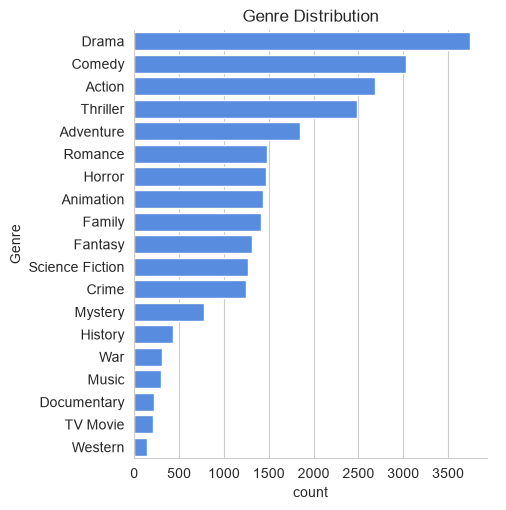

In [56]:
# 📌 Genre Distribution 
sns.catplot(
    y='Genre',
    data=df,
    kind='count',
    order=df['Genre'].value_counts().index,
    color='#4287f5'
)
plt.title("Genre Distribution")
plt.savefig("genre_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
### 📌 Insight
# Drama and Action are among the most frequently occurring genres in the dataset.
# A small number of genres dominate the overall movie collection.
# Understanding genre distribution can support content strategy and audience preference analysis.

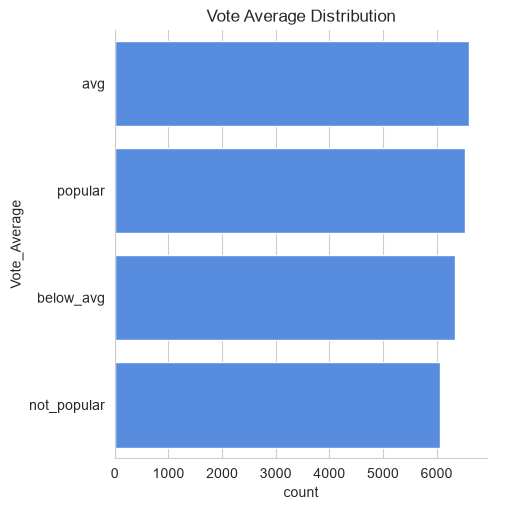

In [54]:
# 📌 Vote Distribution
sns.catplot(
    y='Vote_Average',
    data=df,
    kind='count',
    order=df['Vote_Average'].value_counts().index,
    color='#4287f5'
)
plt.title("Vote Average Distribution")
plt.savefig("vote_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
order=df['Vote_Average'].value_counts().index

In [38]:
df.head(2)

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure


In [ ]:
### 📌 Insight
# Most movies belong to the **Average** vote category.
# Only a small proportion of movies receive very high or very low ratings.
# The distribution indicates that audience ratings are concentrated around the middle range.

In [39]:
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


In [40]:
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25787,2021,The United States vs. Billie Holiday,13.354,152,avg,Music
25788,2021,The United States vs. Billie Holiday,13.354,152,avg,Drama
25789,2021,The United States vs. Billie Holiday,13.354,152,avg,History
25790,1984,Threads,13.354,186,popular,War
25791,1984,Threads,13.354,186,popular,Drama
25792,1984,Threads,13.354,186,popular,Science Fiction


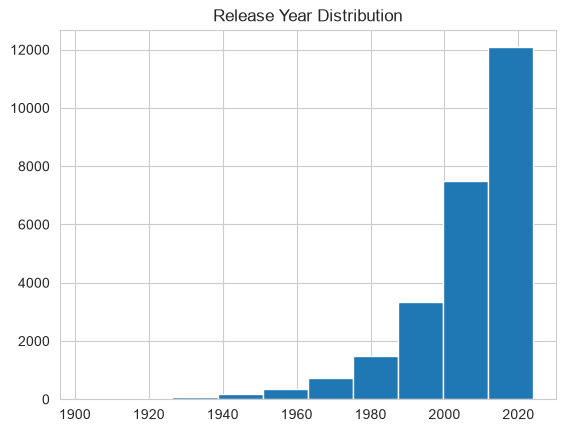

In [55]:
# 📌 Release Year Distribution
df['Release_Date'].hist()
plt.title("Release Year Distribution")
plt.savefig("release_year_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [49]:
### 📌 Insight
# The number of movie releases has increased significantly over recent years.
# Modern movies represent a larger portion of the dataset than older releases.
# This trend reflects the continuous growth of the global film industry.

In [50]:
# 💡 Final Business Insights
# The dataset is dominated by a limited number of highly popular genres.
# Most movies receive average audience ratings, while extremely high and low ratings are relatively uncommon.
# Movie production has shown noticeable growth over time, especially in recent years.
# Feature engineering improved the quality of categorical analysis and visualization.
# Data visualization effectively revealed trends that were not immediately visible in the raw dataset.
# Proper data preprocessing significantly enhanced the reliability and quality of the analysis.
# The insights generated from this project can support content analysis, audience understanding, and data-driven decision-making.

In [51]:
# ✅ Conclusion
# This project successfully demonstrates a complete Exploratory Data Analysis (EDA) workflow using Python. The dataset was cleaned, transformed, and analyzed to uncover meaningful patterns related to movie genres, popularity, audience ratings, and release trends. The project strengthened practical skills in data preprocessing, feature engineering, visualization, and insight generation while following a structured and professional data analytics workflow.